In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
from torchvision.models import resnet18
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm

In [2]:
class CustomImageDataset(Dataset): # данный класс нужен для того, чтобы даталоадер смог проитерироваться по нужным картинкам, применить к ним трансформ и сделать нам батчи
    def __init__(self, ids, labels, img_dir, transform=None):
            self.ids = list(ids) 
            self.labels = list(labels)
            self.img_dir = img_dir
            self.transform = transform

    def __len__(self):
        return len(self.ids) # просто метод, который нужен даталоадеру

    def __getitem__(self, idx):
        img_name = self.ids[idx]  # здесь мы получаем Id картинки
        label = int(self.labels[idx])  # здесь получаем метку класса

        img_path = os.path.join(self.img_dir, img_name) # получаем путь до нужной картинки с правильными слешами (на разных ОП по-разному)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [3]:
def get_bhw_data(batch_size, transform_train): # здесь пишем аналог класса get_cifar10_data из МДЗ2 просто чтобы мы могли потом выполнять все, что могли в МДЗ2
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])

    data_start = "/kaggle/input/bhw-1-dl-2025-2026/bhw1"
    img_dir = os.path.join(data_start, "trainval")
    csv_path = os.path.join(data_start, "labels.csv")

    full_dataset = pd.read_csv(csv_path)

    df_train, df_val = train_test_split(
        full_dataset,
        test_size=0.3,
        shuffle=True,
        random_state=0,
        stratify=full_dataset["Category"]  # здесь мы пишем stratify, чтобы распределение классов в трейне и на валидации было примерно одинаковым
    )

    trainset = CustomImageDataset(
        ids=df_train["Id"], 
        labels=df_train["Category"], 
        img_dir=img_dir, 
        transform=transform_train
    )

    valset = CustomImageDataset(
        ids=df_val["Id"], 
        labels=df_val["Category"], 
        img_dir=img_dir, 
        transform=transform_test
    )

    train_loader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    val_loader = DataLoader(
        valset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    class TestDataset(Dataset):
        def __init__(self, img_dir, transform=None):
            self.img_dir = img_dir
            self.images = sorted(os.listdir(img_dir)) # на всякий случай, чтобы у нас потом предсказания были в правильном порядке
            self.transform = transform

        def __len__(self):
            return len(self.images)

        def __getitem__(self, idx):
            img_path = os.path.join(self.img_dir, self.images[idx])
            image = Image.open(img_path).convert("RGB")

            if self.transform:
                image = self.transform(image)

            return image, self.images[idx]

    test_dataset = TestDataset(
        img_dir=os.path.join(data_start, "test"),
        transform=transform_test
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(40, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(), 
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader, val_loader, test_loader = get_bhw_data(batch_size=256,
                                                         transform_train=transform_train)

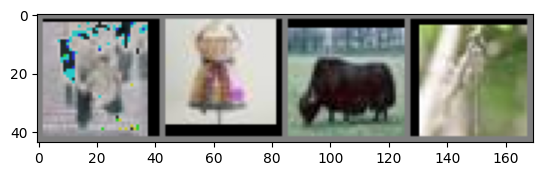

Labels: [86, 5, 56, 145]


In [5]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))
print("Labels:", labels[:4].tolist())

In [6]:
num_classes = 200

model_18 = resnet18(weights=None)
model_18.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_18.maxpool = nn.Identity()
num_ftrs = model_18.fc.in_features
model_18.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, num_classes)
)

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [8]:
model_18 = model_18.to(device)

In [9]:
def mixup_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [10]:
def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1, bby1 = np.clip(cx - cut_w // 2, 0, W), np.clip(cy - cut_h // 2, 0, H)
    bbx2, bby2 = np.clip(cx + cut_w // 2, 0, W), np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

In [11]:
def predict_with_filenames(model, loader):
    model.eval()
    device = next(model.parameters()).device

    filenames = []
    predictions = []

    with torch.no_grad():
        for data, names in loader:
            data = data.to(device)

            output = model(data)
            _, y_pred = torch.max(output, 1)

            filenames.extend(names)
            predictions.extend(y_pred.cpu().tolist())

    return filenames, predictions

In [12]:
def test(model, loader, criterion):
    loss_log = []
    acc_log = []
    model.eval()

    device = next(model.parameters()).device
    with torch.no_grad():
        pbar = tqdm(loader, desc='Evaluation', leave=False)
        for data, target in pbar:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            
            loss = criterion(output, target)
            loss_log.append(loss.item())

            # <your code here>

            _, y_pred = torch.max(output, 1)
            correct = (y_pred == target).sum()
            total = target.shape[0]
            acc = correct/total
            acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader, criterion, scheduler, scaler, device):
    model.train()
    loss_log = []
    
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        
        lam = np.random.beta(1.0, 1.0)
        rand_index = torch.randperm(data.size(0)).to(device)
        target_a, target_b = target, target[rand_index]

        r = np.random.rand()
        if r < 0.5:
            input_data = lam * data + (1 - lam) * data[rand_index, :]
        else:
            # CUTMIX
            input_data = data.clone()
            bbx1, bby1, bbx2, bby2 = rand_bbox(data.size(), lam)
            input_data[:, :, bbx1:bbx2, bby1:bby2] = data[rand_index, :, bbx1:bbx2, bby1:bby2]
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (data.size()[-1] * data.size()[-2]))

        with torch.cuda.amp.autocast():
            output = model(input_data)
            loss = lam * criterion(output, target_a) + (1 - lam) * criterion(output, target_b)
        
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        scheduler.step()
        
        loss_log.append(loss.item())
        
    return np.mean(loss_log)

def train(model, optimizer, n_epochs, train_loader, val_loader, test_loader, scheduler, criterion, scaler, device):
    import pandas as pd
    train_loss_log, val_loss_log, val_acc_log = [], [], []

    for epoch in range(n_epochs):
        train_loss = train_epoch(model, optimizer, train_loader, criterion, scheduler, scaler, device)
        
        val_loss, val_acc = test(model, val_loader, criterion)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")
        
        if wandb.run is not None:
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "lr": current_lr
            })

        train_loss_log.append(train_loss)
        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        if epoch in [79, 89, n_epochs - 1]: 
            print(f"--> Saving submission at epoch {epoch + 1}...")
            filenames, preds = predict_with_filenames(model, test_loader)
            pd.DataFrame({"Id": filenames, "Category": preds}).to_csv(f"submission_epoch_{epoch + 1}.csv", index=False)

    return train_loss_log, val_loss_log, val_acc_log

In [13]:
import wandb
import os

os.environ["WANDB_API_KEY"] = "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"

wandb.login()

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

True

In [14]:
config = {
    "num_classes": 200,
    "epochs": 100,
    "batch_size": 256,
    "max_lr": 0.1,
    "weight_decay": 5e-4,
    "label_smoothing": 0.1,
    "mixup_alpha": 0.2,
    "cutmix_prob": 0.5,
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

In [15]:
if wandb.run is not None:
    wandb.finish()

In [16]:
run = wandb.init(
    project="BHW1-Image-Classification",
    name="ResNet18-Mixup-CutMix-OneCycle",
    config=config
)

wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260123_144149-1sczk4g3
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ResNet18-Mixup-CutMix-OneCycle
wandb: ⭐️ View project at https://wandb.ai/alex-shayko04-new-economic-school/BHW1-Image-Classification
wandb: 🚀 View run at https://wandb.ai/alex-shayko04-new-economic-school/BHW1-Image-Classification/runs/1sczk4g3


In [17]:
optimizer = optim.SGD(
    model_18.parameters(),
    lr=config["max_lr"], 
    momentum=0.9, 
    weight_decay=config["weight_decay"], 
    nesterov=True
)

criterion = nn.CrossEntropyLoss(label_smoothing=config["label_smoothing"])
scaler = torch.cuda.amp.GradScaler()
 
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config["max_lr"],
    steps_per_epoch=len(train_loader),
    epochs=config["epochs"],
    pct_start=0.2,
    div_factor=25,
    final_div_factor=1000
)

train_loss_log, val_loss_log, val_acc_log = train(
    model=model_18, 
    optimizer=optimizer, 
    n_epochs=config["epochs"], 
    train_loader=train_loader, 
    val_loader=val_loader, 
    test_loader=test_loader, 
    scheduler=scheduler, 
    criterion=criterion, 
    scaler=scaler, 
    device=config["device"]
)

/tmp/ipykernel_24/657155115.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_24/2560320540.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Evaluation:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 000 | Train Loss: 5.2919 | Val Loss: 5.0677 | Val Acc: 0.0325 | LR: 0.004591


Evaluation:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 5.1929 | Val Loss: 4.9417 | Val Acc: 0.0425 | LR: 0.006350


...

Evaluation:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 098 | Train Loss: 3.6699 | Val Loss: 2.7004 | Val Acc: 0.5142 | LR: 0.000042


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aa8709ec2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7aa8709ec2c0>    
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
      if w.is_alive(): 
 Exception ignored in: ^ <function _MultiProcessingDataLoaderIter.__del__ at 0x7aa8709ec2c0>^
^ ^Traceback (most recent call last):
  ^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.p

Evaluation:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 099 | Train Loss: 3.6595 | Val Loss: 2.6931 | Val Acc: 0.5148 | LR: 0.000004
--> Saving submission at epoch 100...


In [18]:
wandb.finish()

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:      epoch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▆▇▇▇▇▇▇▇▇██
wandb:         lr ▁▂▂▃▄▅▇█████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
wandb: train_loss █▇▇▇▆▅▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
wandb:    val_acc ▁▁▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇██████
wandb:   val_loss █▇▆▅▅▄▄▄▄▄▃▄▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:      epoch 99
wandb:         lr 0.0
wandb: train_loss 3.65945
wandb:    val_acc 0.5148
wandb:   val_loss 2.69306
wandb: 
wandb: 🚀 View run ResNet18-Mixup-CutMix-OneCycle at: https://wandb.ai/alex-shayko04-new-economic-school/BHW1-Image-Classification/runs/1sczk4g3
wandb: ⭐️ View project at: https://wandb.ai/alex-shayko04-new-economic-school/BHW1-Image-Classification
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260123_144149-1sczk4g3/logs
